# RadHarmony: Evaluating a Foundation Model Part 1

This notebook evaluates foundation models on radiology datasets. It assumes you
are comfortable loading a dataset in RadHarmony.

It scores **frozen** foundation-model features three ways, each a different task:

1. **Linear probe** (classification): freeze MedSigLIP (MedGemma's image encoder)
   and fit a small head for TB classification on Montgomery.
2. **Zero-shot** (no probe training): BiomedCLIP scores images by text-prompt
   similarity, so the prompt wording is the only knob.
3. **Segmentation probe**: a small conv head over the frozen features predicts a
   lung mask on Montgomery.

Every evaluator returns the same metrics-table shape, so results are comparable
across models and tasks. Each section ends with a **"try it yourself"** cell that
swaps in a different encoder or dataset, leaving a few arguments for you to fill in.

Visual question answering and report generation follow in Parts 2 and 3.

In [ ]:
import os

GPU_ID = 7
os.environ["CUDA_VISIBLE_DEVICES"] = str(GPU_ID)
DEVICE = "cuda"

In [3]:
from radharmony.dataset import MontgomeryCXRDataset

MONTGOMERY_DIR = "/mnt/NAS4/datasets/external/Montgomery-CXR/MontgomerySet/CXR_png"

## Foundation models and linear probes

A **foundation model** is pre-trained on lots of data; its representations
transfer to new tasks without retraining. The cheapest way to test one is a
**linear probe**: freeze the model, turn each image into an embedding, then fit a
small classifier on top.

MedGemma is a vision-language model, so its native output is text, but its image
encoder [MedSigLIP](https://huggingface.co/google/medsiglip-448) (shipped
separately by Google) produces embeddings. Below we probe MedSigLIP on
tuberculosis classification (Montgomery). Each encoder expects its own
normalization, so we pass the recipe's `transform` to the dataset;
`LinearProbeEvaluator` then embeds every image, runs 5-fold cross-validation, and
scores each held-out fold.

In [4]:
from radharmony.evaluator.backbones import make_medsiglip
from radharmony.evaluator import LinearProbeEvaluator

# MedSigLIP is MedGemma-4B's image encoder (google/medsiglip-448, gated on HF).
# The recipe returns (transform, image encoder, text encoder, processor); a
# linear probe needs only the first two.
transform, encoder, _text_encoder, _processor = make_medsiglip(
    device=DEVICE, output_keys={"img", "cls"}
)

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

In [5]:
probe_ds = MontgomeryCXRDataset(
    base_image_dir=MONTGOMERY_DIR,
    transform=transform,  # MedSigLIP's preprocessing, not RadHarmony's default
    output_cls=True,
    cache_dir="/mnt/NAS4/projects/fli40_sharing/datathon26_summer_school/cache_medsiglip_montgomery",
)

# LinearProbeEvaluator does the rest: embed every image, run 5-fold CV, score folds.
probe = LinearProbeEvaluator(
    image_encoder=encoder,
    dataset=probe_ds,
    n_folds=5,
    batch_size=32,
    device=DEVICE,
    embedding_cache="/mnt/NAS4/projects/fli40_sharing/datathon26_summer_school/embd_medsiglip_montgomery",  # embeddings reused on re-runs
)
results = probe.evaluate()

# Average metrics across the folds, per label.
results.groupby("label")[["auroc", "auprc", "f1"]].mean()

,auroc,auprc,f1
label,,,
macro_average,0.972443,0.975077,0.947694
tb,0.972443,0.975077,0.947694


### Reporting uncertainty: confidence intervals

`.mean()` hides the fold-to-fold spread. Two ways to get error bars:

1. **Across folds.** Five folds is too few for percentiles, so report the sample
   **std** or a **t-interval** (mean +/- t(0.975, df=n-1) * std / sqrt(n)).
2. **Bootstrapping.** In fixed-split mode RadHarmony resamples the test rows
   `n_bootstrap` times; the 2.5 / 97.5 percentiles over resamples are the CI
   `save_results()` writes. The cell below trains on Montgomery and tests on
   VinDr-CXR (a cross-dataset TB transfer check on the one label both share).

In [ ]:
import numpy as np
from scipy import stats


# 1) CI across folds. Five folds is too few for empirical percentiles, so
# summarize the fold-to-fold spread with the sample std (ddof=1) and a
# small-sample t-interval: mean +/- t(0.975, df=n-1) * std / sqrt(n).
def _t_ci(s, side):
    vals = s.to_numpy()
    n = len(vals)
    mean = np.nanmean(vals)
    sem = np.nanstd(vals, ddof=1) / np.sqrt(n)
    half = stats.t.ppf(0.975, df=n - 1) * sem
    return mean - half if side == "lo" else mean + half


fold_ci = (
    results.groupby("label")["auroc"]
    .agg(
        mean="mean",
        std=lambda s: np.nanstd(s.to_numpy(), ddof=1),
        ci_lo=lambda s: _t_ci(s, "lo"),
        ci_hi=lambda s: _t_ci(s, "hi"),
    )
    .round(4)
)
fold_ci

,mean,std,ci_lo,ci_hi
label,,,,
macro_average,0.9724,0.0251,0.9413,1.0036
tb,0.9724,0.0251,0.9413,1.0036


In [7]:
# 2) CI from bootstrapping. Bootstrapping needs a held-out test set, so train the
# probe on Montgomery and TEST on VinDr-CXR: a cross-dataset TB generalization
# check. Both datasets now expose a `tuberculosis` label, so probe with the one
# finding they share.
from radharmony.dataset import VinDrCXRTestDataset

VINDR_ROOT = "/mnt/NAS4/datasets/external/VinDr-CXR/physionet.org/files/vindr-cxr/1.0.0"

train_mont = MontgomeryCXRDataset(
    base_image_dir=MONTGOMERY_DIR,
    transform=transform,  # MedSigLIP's preprocessing
    output_cls=True,
    cache_dir="/mnt/NAS4/projects/fli40_sharing/datathon26_summer_school/cache_medsiglip_montgomery",
)
vindr_test = VinDrCXRTestDataset(
    base_image_dir=f"{VINDR_ROOT}/test/",
    csv_path=f"{VINDR_ROOT}/annotations/image_labels_test.csv",
    transform=transform,
    output_cls=True,
    cache_dir="/mnt/NAS4/projects/fli40_sharing/datathon26_summer_school/cache_medsiglip_vindr_test/",
)

boot_probe = LinearProbeEvaluator(
    image_encoder=encoder,
    train_dataset=train_mont,
    test_dataset=vindr_test,
    labels=["tuberculosis"],  # the one finding both datasets share
    n_bootstrap=1000,  # resample the test rows 1000x -> bootstrap CI
    batch_size=32,
    device=DEVICE,
    embedding_cache="/mnt/NAS4/projects/fli40_sharing/datathon26_summer_school/embd_medsiglip_tb_transfer",
)
boot_results = boot_probe.evaluate()

# bootstrap == -1 is the point estimate; 0..999 are the resamples we summarize.
# Many resamples -> the 2.5 / 97.5 percentiles are a sound CI.
resamples = boot_results[boot_results["bootstrap"] >= 0]
boot_ci = (
    resamples.groupby("label")["auroc"]
    .agg(
        mean="mean",
        ci_lo=lambda s: np.nanpercentile(s, 2.5),
        ci_hi=lambda s: np.nanpercentile(s, 97.5),
    )
    .round(4)
)
boot_ci

extracting embeddings:   0%|          | 0/5 [00:00<?, ?batch/s]

extracting embeddings:   0%|          | 0/94 [00:00<?, ?batch/s]

,mean,ci_lo,ci_hi
label,,,
macro_average,0.856,0.8272,0.8833
tuberculosis,0.856,0.8272,0.8833


A per-label metrics table (AUROC, AUPRC, F1, and more), the shape **every**
RadHarmony evaluator returns, so scores across models are directly comparable.
AUROC measures how well the model separates positives from negatives (1.0 perfect,
0.5 chance). k-NN, SVM, prototype, zero-shot, fine-tune, and segmentation all
share this interface.

### Seeing the predictions

The same probe also assigns a probability to each image. Reusing the cached
embeddings, we train the TB head on one fold's patients and read off `P(TB)` for a
few held-out validation images, each paired with its true label.

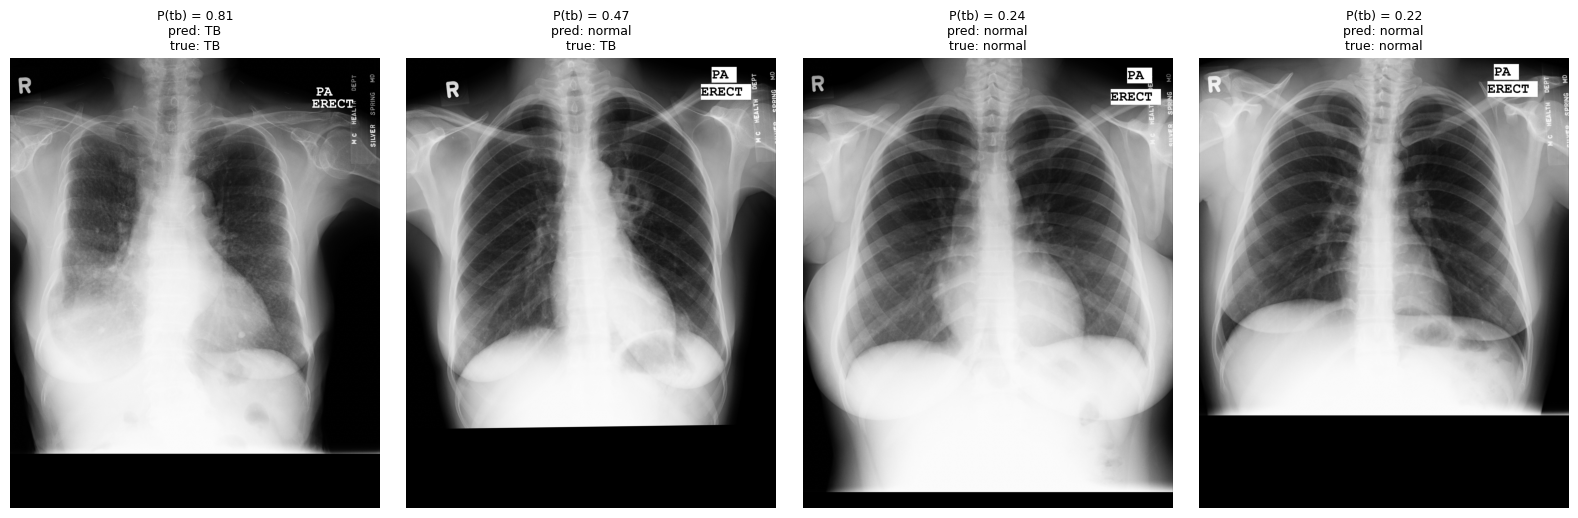

In [5]:
from viz_helpers import show_predictions

show_predictions(probe, probe_ds, MONTGOMERY_DIR)

### Try it yourself: a different encoder, a different dataset

The probe above ran **MedSigLIP** on **Montgomery** (one label: TB). The evaluator
doesn't care which encoder or dataset it gets, so swap both and the call is identical.
Below: **RAD-DINO** (`make_raddino`, a CXR-specialized DINOv2) probed on **VinDr-CXR**,
a 28-finding *multi-label* benchmark, giving one AUROC row per finding plus a
`macro_average`.

> **The "try it yourself" cells leave some arguments as `...`.** Look each one up in
> the linked docs and fill it in. This applies to all five exercises below.

Vision-only recipes (`make_raddino`, `make_dinov3`) return `(transform, encoder)`;
CLIP-family recipes (`make_medsiglip`, `make_biomed_clip`) return a 4-tuple, so
unpack the extra two with `*_`.

In [ ]:
from radharmony.evaluator.backbones import make_raddino
from radharmony.dataset import VinDrCXRTestDataset

# TODO: swap make_raddino for another recipe. Vision-only recipes
# (make_raddino, make_dinov3, make_eva_x) return (transform, encoder);
# for a 4-tuple recipe use:  transform, encoder, *_ = make_medsiglip(...)
#
# FILL IN output_keys: which keys does a *classification* probe need?
#   docs: https://f10409.github.io/RadHarmony/backbones/raddino.html
transform, encoder = make_raddino(device=DEVICE, output_keys=...)

# VinDr-CXR test split (DICOM): 28 findings, multi-label.
VINDR_DIR = (
    "/mnt/NAS4/datasets/external/VinDr-CXR/physionet.org/files/vindr-cxr/1.0.0/test/"
)
vindr_ds = VinDrCXRTestDataset(
    base_image_dir=VINDR_DIR,
    transform=transform,  # the encoder's own preprocessing
    output_cls=...,  # FILL IN: what does a probe read? docs: https://f10409.github.io/RadHarmony/datasets/vindr_cxr.html
    cache_dir="/mnt/NAS4/projects/fli40_sharing/datathon26_summer_school/cache_raddino_vindr_test/",
)

probe = LinearProbeEvaluator(
    image_encoder=encoder,
    dataset=vindr_ds,
    n_folds=5,
    batch_size=32,
    device=DEVICE,
    embedding_cache="/mnt/NAS4/projects/fli40_sharing/datathon26_summer_school/embd_raddino_vindr_test",
)
results = probe.evaluate()

# 28 findings -> 28 label rows + a macro_average; show the ten best-separated.
(
    results.groupby("label")[["auroc", "auprc", "f1"]]
    .mean()
    .sort_values("auroc", ascending=False)
    .head(10)
)

### Try it yourself: zero-shot, no probe training

A linear probe still fits a small classifier. A **vision-language** model can skip
even that: embed the image, embed a text prompt per class, and score by cosine
similarity. No training, no folds, so the *prompt wording* is the only knob.
`make_biomed_clip` hands back a text encoder and tokenizer alongside the image
encoder, and `ZeroShotEvaluator` turns per-label prompts into class prototypes.
Here **BiomedCLIP** scores **RSNA Pneumonia** images for `lung_opacity` vs `normal`;
reword the prompts and watch AUROC move.

In [20]:
from radharmony.evaluator import ZeroShotEvaluator
from radharmony.evaluator.backbones import make_biomed_clip
from radharmony.dataset import VinDrCXRTestDataset

In [21]:
# make_biomed_clip returns FOUR objects. Which is the text encoder? the tokenizer?
#   docs: https://f10409.github.io/RadHarmony/backbones/biomed_clip.html
transform, encoder, text_encoder, tokenizer = make_biomed_clip(device=DEVICE)

In [22]:
_DIR = "/mnt/NAS4/datasets/external/VinDr-CXR/physionet.org/files/vindr-cxr/1.0.0/test/"
_CSV = "/mnt/NAS4/datasets/external/VinDr-CXR/physionet.org/files/vindr-cxr/1.0.0/annotations/image_labels_test.csv"

zs_ds = VinDrCXRTestDataset(
    base_image_dir=_DIR,
    csv_path=_CSV,
    transform=transform,
    output_cls=True,
    cache_dir="/mnt/NAS4/projects/fli40_sharing/datathon26_summer_school/cache_biomedclip_vindr_test/",
)

In [ ]:
ev = ZeroShotEvaluator(
    image_encoder=encoder,
    text_encoder=...,  # FILL IN: which object from make_biomed_clip? docs: https://f10409.github.io/RadHarmony/evaluator/zero_shot.html
    tokenizer=...,  # FILL IN: ditto
    dataset=zs_ds,
    labels=...,  # FILL IN: two of RSNA's 3 classes; LABEL_COLS at https://f10409.github.io/RadHarmony/datasets/rsna_pneumonia_kaggle.html
    # # The prompts ARE the experiment, so reword them freely.
    prompts={
        "cardiomegaly": [
            "a chest x-ray showing cardiomegaly",
        ],
    },
    # negative_prompts={
    #     "lung_opacity": ["a normal chest x-ray with clear lungs"],
    # },
    embedding_cache="/mnt/NAS4/projects/fli40_sharing/datathon26_summer_school/embd_biomedclip_vindr_test",
)
ev.evaluate()

### Segmentation probe

The same frozen encoder can be probed for **segmentation** instead of
classification. In segmentation mode (`output_keys={"img", "mask"}`) the encoder
returns dense `[B, D, H, W]` feature maps rather than one vector per image, and
`LinearProbeSegEvaluator` trains a small 1x1 conv head on top to predict a mask.

We segment the **lungs** on Montgomery, which ships left+right lung masks.
Everything else (frozen backbone, 5-fold CV, per-class metrics) mirrors the
classification probe above.

In [28]:
from radharmony.evaluator import LinearProbeSegEvaluator

# Same MedSigLIP, now in segmentation mode: output_keys={"img", "mask"} makes the
# encoder emit dense [B, D, H, W] feature maps instead of one [B, D] vector.
seg_transform, seg_encoder, _text_encoder, _processor = make_medsiglip(
    device=DEVICE, output_keys={"img", "mask"}
)

# Montgomery ships left+right lung masks; output_mask=True fuses them into one
# binary lung mask per image, written to mask_output_dir.
seg_ds = MontgomeryCXRDataset(
    base_image_dir=MONTGOMERY_DIR,
    transform=seg_transform,
    output_mask=True,
    mask_output_dir="/mnt/NAS4/projects/fli40_sharing/datathon26_summer_school/montgomery_lung_masks",
    cache_dir="/mnt/NAS4/projects/fli40_sharing/datathon26_summer_school/cache_medsiglip_montgomery",
)

# Trains a 1x1 conv head over the frozen features per fold (background + lung).
seg_probe = LinearProbeSegEvaluator(
    image_encoder=seg_encoder,
    dataset=seg_ds,
    num_classes=2,
    n_folds=5,
    epochs=20,
    batch_size=8,
    device=DEVICE,
)
seg_results = seg_probe.evaluate()

# Average Dice / IoU across folds, per class.
seg_results.groupby("label")[["dice", "iou"]].mean()

training: 100%|██████████| 20/20 [14:28<00:00, 43.41s/epoch, dice=0.9170, loss=0.1142]


,dice,iou
label,,
class_0,0.975263,0.951865
class_1,0.924205,0.860076
macro_average,0.924205,0.860076


A per-class table of segmentation metrics (Dice, IoU, pixel accuracy, sensitivity,
specificity). `class_1` is the lung; `macro_average` aggregates the foreground
classes. Dice measures overlap between predicted and true mask (1.0 perfect, 0.0
disjoint). `ConvProbeSegEvaluator` (deeper head) and `UPerNetSegEvaluator` (full
decoder) drop in through the same interface.

### Seeing the predicted masks

`fit()` trains one deployment head (no k-fold) and `predict(..., return_images=True)`
runs it over the inner-val slice `fit()` held out, returning the resized image,
ground-truth mask, and predicted mask per example, ready for overlays.

Fusing lung masks: 100%|██████████| 138/138 [00:00<00:00, 20008.09it/s]


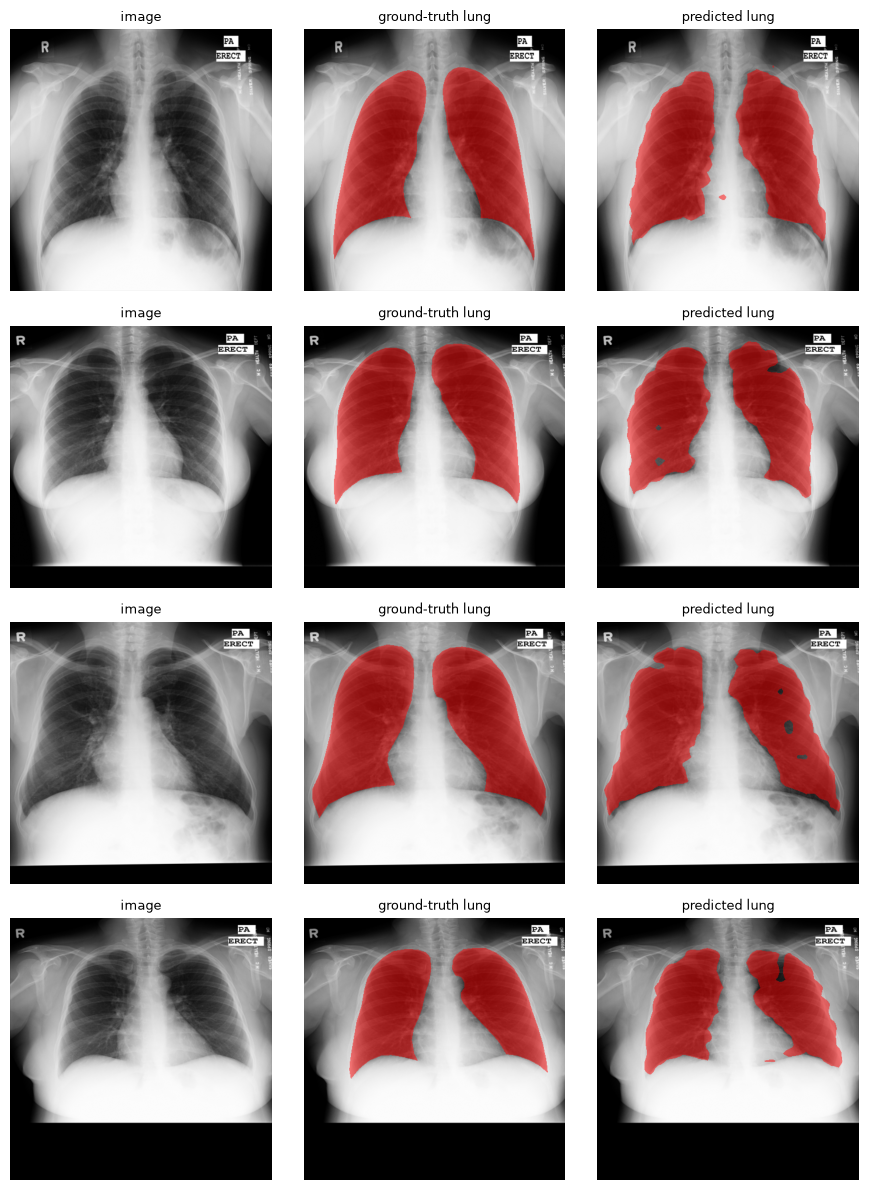

In [29]:
from viz_helpers import show_masks

show_masks(seg_probe, seg_ds)

### Try it yourself: segment a different finding with a different encoder

Point the same `LinearProbeSegEvaluator` at **SIIM-ACR Pneumothorax** with a
**RAD-DINO** backbone to segment the pneumothorax region instead. SIIM ships
run-length-encoded masks; `output_mask=True` + `mask_output_dir` decodes them to
PNGs once (cached after). Everything else stays the same as the lung probe: frozen
backbone in `output_keys={"img", "mask"}` mode, 5-fold CV, Dice / IoU per class.

In [ ]:
from radharmony.evaluator.backbones import make_raddino
from radharmony.dataset import SIIMACRPTXTrainDataset

# FILL IN output_keys for *segmentation* mode (dense [B, D, H, W] maps, not one vector).
#   docs: https://f10409.github.io/RadHarmony/backbones/raddino.html
seg_transform, seg_encoder = make_raddino(device=DEVICE, output_keys=...)

SIIM_DIR = "/mnt/NAS3/datasets/external/SIIM_ACR_Pneumothorax/dicom-images-train/"
SIIM_CSV = "/mnt/NAS3/datasets/external/SIIM_ACR_Pneumothorax/train-rle.csv"
# RLE masks in the CSV are decoded to PNGs under mask_output_dir on first load.
siim_ds = SIIMACRPTXTrainDataset(
    base_image_dir=SIIM_DIR,
    csv_path=SIIM_CSV,
    transform=seg_transform,
    output_mask=True,
    mask_output_dir="/mnt/NAS4/projects/fli40_sharing/datathon26_summer_school/siim_ptx_masks",
    cache_dir="/mnt/NAS4/projects/fli40_sharing/datathon26_summer_school/cache_raddino_siim_ptx",
)

seg_probe = LinearProbeSegEvaluator(
    image_encoder=seg_encoder,
    dataset=siim_ds,
    num_classes=...,  # FILL IN: background + pneumothorax = ? docs: https://f10409.github.io/RadHarmony/evaluator/linear_probe_seg.html
    n_folds=5,
    epochs=20,
    batch_size=8,
    device=DEVICE,
)
seg_probe.evaluate().groupby("label")[["dice", "iou"]].mean()

## Summary

You scored frozen foundation-model features three ways, a linear probe, zero-shot prompting, and a segmentation probe, each returning the same comparable metrics table. Parts 2 and 3 (notebooks 6 and 7) move on to generative tasks: visual question answering and report generation.